# Relazione di laboratorio di Fisica Computazionale: metodi risolutivi delle equazioni differenziali ordinarie applicate al pendolo semplice.

In [125]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [126]:
import numpy as np
import matplotlib.pyplot as plt

In [127]:
L = 1
m = 1
g = 9.81
theta0 = 0.1
theta02 = 0.5
theta03 = np.pi/2
theta04 = np.radians(172)
dt = 0.01
dt2 = 0.001
dt3 = 0.1
t_fin = 20
t_fin2 = 100
times = np.arange(0, t_fin, dt)
long_times = np.arange(0, t_fin2, dt)
very_long_times = np.arange(0, t_fin2, dt2)

## Introduzione teorica del problema in esame
Nell'ambito dei metodi risolutivi delle equazioni differenziali ordinarie il primo metodo introdotto è quello di Eulero con la variazione di Eulero-Cromer. Uno dei casi di studio fisici che prevede la possibilità di risoluzione analitica riguarda il pendolo semplice in cui consideriamo una massa che oscilla. Per poter risolvere questo problema analiticamente dobbiamo utilizzare diverse approssimazioni: il filo a cui è sospesa la massa lo consideriamo inestensibile e supponiamo che l'angolo che il filo forma con la verticale sia abbastanza piccolo (meno di 7°) così da poter sfruttare l'approssimazione del seno sviluppato con la formula di Taylor in cui vengono ignorati tutti i termini successivi al primo: $$\sin(\theta)\approx \theta + o(\theta^2).$$

Possiamo utilizzare la seconda legge della dinamica e applicarla alla componente tangenziale del moto per ottenere la seguente equazione: $$\frac{d^2 \theta}{dt^2} = -\frac{g}{L}\sin(\theta),$$ in cui $g$ è l'accelerazione gravitazionale e $L$ è la lunghezza del filo. Questa è un'equazione differenziale del secondo ordine ma il metodo di Eulero, e anche la sua variazione, si applica a equazioni differenziali del primo ordine, quindi dobbiamo riscrivere l'equazione del moto ottenuta in un sistema di equazioni differenziali del primo ordine: $$\frac{d\theta}{dt}=\omega,\qquad \frac{d\omega}{dt}=-\frac{g}{L}\sin(\theta).$$ Un'ulteriore approssimazione necessaria riguarda l'assenza di attrito che ci permette di conservare l'energia meccanica totale del sistema: $$E=\frac{mL^2 \omega^2}{2}+mgL(1-\cos(\theta)).$$

L'approssimazione delle piccole oscillazioni trasforma l'equazione di partenza in quella dell'oscillatore armonico con frequenza angolare naturale $\omega_0 = \sqrt{g/L}$, la cui soluzione è data dalla seguente legge del moto: $$\theta(t)=\theta_0 \cos(\omega_0 t)+\left(\frac{\omega_{init}}{\omega_0}\right)\sin(\omega_0 t),$$ con $\theta_0$ che rappresenta l'angolo iniziale e $\omega_{init}$ che rappresenta la velocità angolare iniziale nel caso in cui venga dato un colpo alla massa all'instante $t=0$.

Possiamo plottare la soluzione analitica del pendolo semplice per visionarne l'andamento nel tempo:

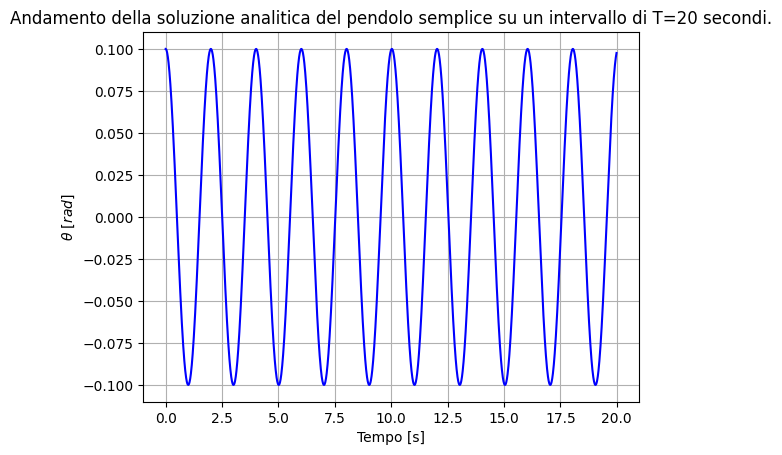

In [128]:
def f_analitica(theta0: float, times: list[float], omega_in: float = 0) -> list[float]:
    omega0 = np.sqrt(g/L)
    points = []
    for t in times:
        theta = theta0 * np.cos(omega0 * t) + (omega_in / omega0) * np.sin(omega0 * t) 
        points.append(theta)

    return np.array(points)

plt.plot(times, f_analitica(theta0=theta0, times=times), color="blue")
plt.grid()
plt.xlabel("Tempo [s]")
plt.ylabel(r"$\theta\ [rad]$")
plt.title("Andamento della soluzione analitica del pendolo semplice su un intervallo di T=20 secondi.")
plt.show()

Come ci aspettavamo l'andamento del pendolo semplice è quello di un oscillatore armonico. Implementiamo ora il metodo di Eulero, in cui sviluppiamo con la formula di Taylor e ignoriamo i termini di ordine superiore al secondo: $$y_{n+1}=y_n + h \cdot f(t_n, y_n).$$
Nel caso specifico del pendolo semplice abbiamo che le equazioni di aggiornamento sono: $$\theta_{n+1}=\theta_n + h \cdot \omega_n,\qquad \omega_{n+1}=\omega_n - h \cdot \frac{g}{L} \cdot \sin(\theta_n).$$

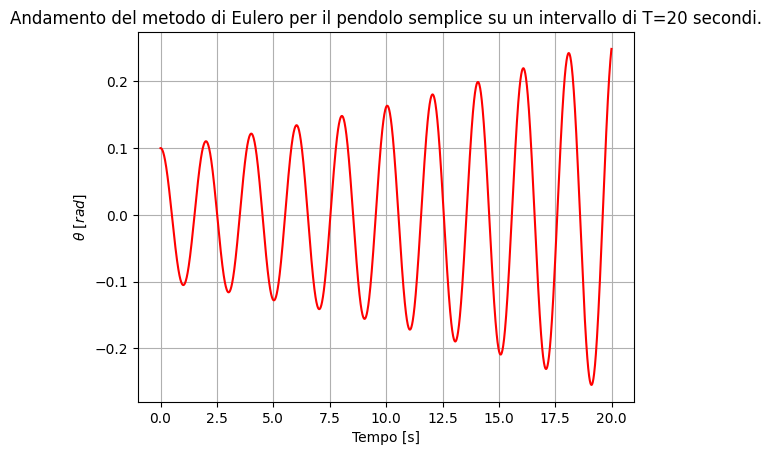

In [129]:
def eulero(theta0: float, h: float, times: list[float]) -> tuple[list[float], list[float]]:
    omega0 = 0
    pos, vel = [theta0], [omega0]

    for t in times[:-1]:
        theta = theta0 + h * omega0
        omega = omega0 - h * (g/L) * np.sin(theta0)
        pos.append(theta)
        vel.append(omega)
        theta0, omega0 = theta, omega

    return np.array(pos), np.array(vel)

pos, _ = eulero(theta0=theta0, h=dt, times=times)
plt.plot(times, pos, color="red")
plt.grid()
plt.xlabel("Tempo [s]")
plt.ylabel(r"$\theta\ [rad]$")
plt.title("Andamento del metodo di Eulero per il pendolo semplice su un intervallo di T=20 secondi.")
plt.show()

Si può notare che le oscillazioni aumentano in ampiezza al passare del tempo: questo è in accordo con la teoria dato che il metodo di Eulero è sconsigliato per simulazioni lunghe dato che non conserva l'energia. Creiamo un grafico con entrambi i plot per sottolineare questa discrepanza:

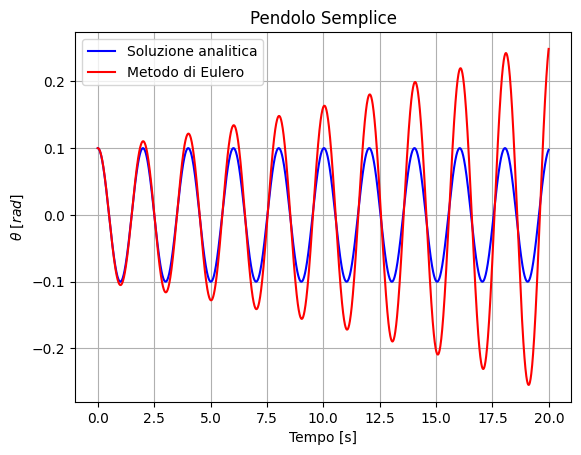

In [130]:
plt.plot(times, f_analitica(theta0=0.1, times=times), label="Soluzione analitica", color="blue")
pos, _ = eulero(theta0=theta0, h=dt, times=times)
plt.plot(times, pos, label="Metodo di Eulero", color="red")
plt.xlabel("Tempo [s]")
plt.ylabel(r"$\theta\ [rad]$")
plt.title("Pendolo Semplice")
plt.legend()
plt.grid(True)
plt.show()

Per migliorare l'approssimazione numerica possiamo utilizzare la variazione simplettica, cioè che conserva l'energia, di Eulero-Cromer. In questo caso viene prima aggiornata la velocità e successivamente viene aggiornata la posizione utilizzando la nuova velocità:

In [131]:
def eulero_cromer(theta0: float, h: float, times: list[float]) -> tuple[list[float], list[float]]:
    omega0 = 0
    pos, vel = [theta0], [omega0]

    for t in times[:-1]:
        omega = omega0 - h * (g/L) * np.sin(theta0)
        theta = theta0 + h * omega
        pos.append(theta)
        vel.append(omega)
        theta0, omega0 = theta, omega

    return np.array(pos), np.array(vel)

Creiamo ora un grafico unico con i tre plot per compararne le differenze:

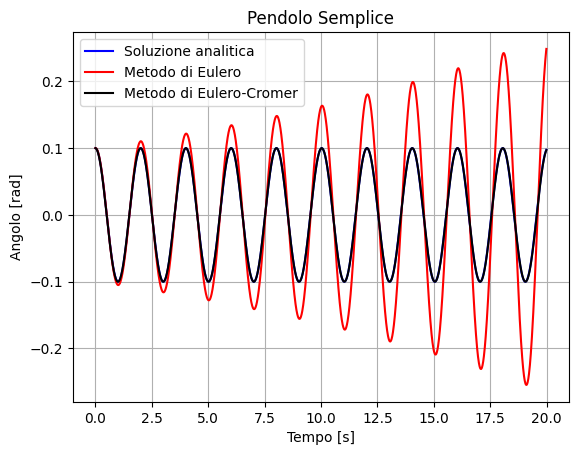

In [132]:
plt.plot(times, f_analitica(theta0=theta0, times=times), label="Soluzione analitica", color="blue")
pos, _ = eulero(theta0=theta0, h=dt, times=times)
plt.plot(times, pos, label="Metodo di Eulero", color="red")
pos_ec, _ = eulero_cromer(theta0=theta0, h=dt, times=times)
plt.plot(times, pos_ec, label="Metodo di Eulero-Cromer", color="black")
plt.xlabel("Tempo [s]")
plt.ylabel("Angolo [rad]")
plt.title("Pendolo Semplice")
plt.legend()
plt.grid(True)
plt.show()

Possiamo notare come l'approssimazione di Eulero-Cromere e la soluzione analitica siano indistinguibili per questo tempo di simulazione. Possiamo confrontare il metodo di Eulero con la sua variazione di Eulero-Cromer confrontando gli errori medi e massimi.

In [133]:
err_m = abs(sum(pos - f_analitica(theta0=theta0, times=times)) / (len(pos)))
err_max = max(pos - f_analitica(theta0=theta0, times=times))
err_ec_m = abs(sum(pos_ec - f_analitica(theta0=theta0, times=times)) / len(pos_ec))
err_ec_max = max(pos_ec - f_analitica(theta0=theta0, times=times))

Per il metodo di Eulero otteniamo: $$\text{errore medio}\ = 10^{-3},\qquad \text{errore massimo}\ = 0.15,$$ mentre per il metodo di Eulero-Cromer otteniamo: $$\text{errore medio}\ = 10^{-5},\qquad \text{errore massimo}\ = 10^{-3}.$$ Possiamo anche plottare gli errori contro i tempi per vederne l'andamento:

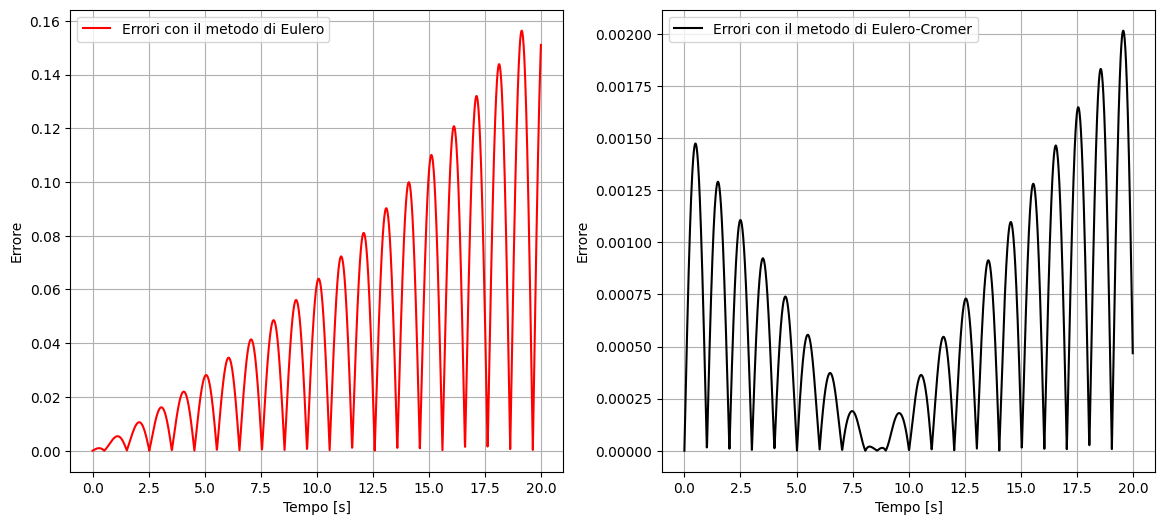

In [135]:
err_eu = abs(pos - f_analitica(theta0=theta0, times=times))
err_ec = abs(pos_ec - f_analitica(theta0=theta0, times=times))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(times, err_eu, label="Errori con il metodo di Eulero", color="red")
ax1.set_xlabel("Tempo [s]")
ax1.set_ylabel("Errore")
ax1.grid(True)
ax1.legend()
ax2.plot(times, err_ec, label="Errori con il metodo di Eulero-Cromer", color="black")
ax2.set_xlabel("Tempo [s]")
ax2.set_ylabel("Errore")
ax2.grid(True)
ax2.legend()
plt.show()

Notiamo visivamente quello che abbiamo affermato prima: il metodo di Eulero tende ad accumulare errore al passare del tempo perché non conserva l'energia e quindi l'ampiezza delle oscillazioni aumenta mentre la variazione di Eulero-Cromer è simplettica e l'energia tende ad oscillare attorno al valore corretto della soluzione analitica.

In [136]:
t1 = np.arange(0, 20, 0.001)
t2 = np.arange(0, 20, 0.01)
t3 = np.arange(0, 20, 0.1)

eu1, _ = eulero(theta0=theta0, h=0.001, times=t1)
ec1, _ = eulero_cromer(theta0=theta0, h=0.001, times=t1)

eu2, _ = eulero(theta0=theta0, h=0.01, times=t2)
ec2, _ = eulero_cromer(theta0=theta0, h=0.01, times=t2)

eu3, _ = eulero(theta0=theta0, h=0.1, times=t3)
ec3, _ = eulero_cromer(theta0=theta0, h=0.1, times=t3)

eu1_m = np.mean(eu1 - f_analitica(theta0=theta0, times=t1))
eu2_m = np.mean(eu2 - f_analitica(theta0=theta0, times=t2))
eu3_m = np.mean(eu3 - f_analitica(theta0=theta0, times=t3))

ec1_m = np.mean(ec1 - f_analitica(theta0=theta0, times=t1))
ec2_m = np.mean(ec2 - f_analitica(theta0=theta0, times=t2))
ec3_m = np.mean(ec3 - f_analitica(theta0=theta0, times=t3))

eu1_max = max(eu1 - f_analitica(theta0=theta0, times=t1))
eu2_max = max(eu2 - f_analitica(theta0=theta0, times=t2))
eu3_max = max(eu3 - f_analitica(theta0=theta0, times=t3))

ec1_max = max(ec1 - f_analitica(theta0=theta0, times=t1))
ec2_max = max(ec2 - f_analitica(theta0=theta0, times=t2))
ec3_max = max(ec3 - f_analitica(theta0=theta0, times=t3))

Gli errori ottenuti per vari valori di $h$ sono i seguenti:
$$h=0.001:\qquad E_{max}=10^{-2},\ E_{mean}=-10^{-4};\quad E-C_{max}=10^{-3},\ E-C_{mean}=-10^{-5}$$
$$h=0.01:\qquad E_{max}=0.15,\ E_{mean}=-10^{-3};\quad E-C_{max}=10^{-3},\ E-C_{mean}=-10^{-5}$$
$$h=0.1:\qquad E_{max}=-26.61,\ E_{mean}=1.82;\quad E-C_{max}=10^{-2},\ E-C_{mean}=10^{-4}$$

Proviamo ora ad analizzare l'andamento dell'energia in funzione del tempo e per far questo utilizziamo lo spazio delle fasi. Partiamo da $\theta=0.5\ \text{rad}$ e simuliamo l'energia per $T=100$ periodi: notiamo che per la soluzione analitica otteniamo un'ellisse che rappresenta la conservazione dell'energia.

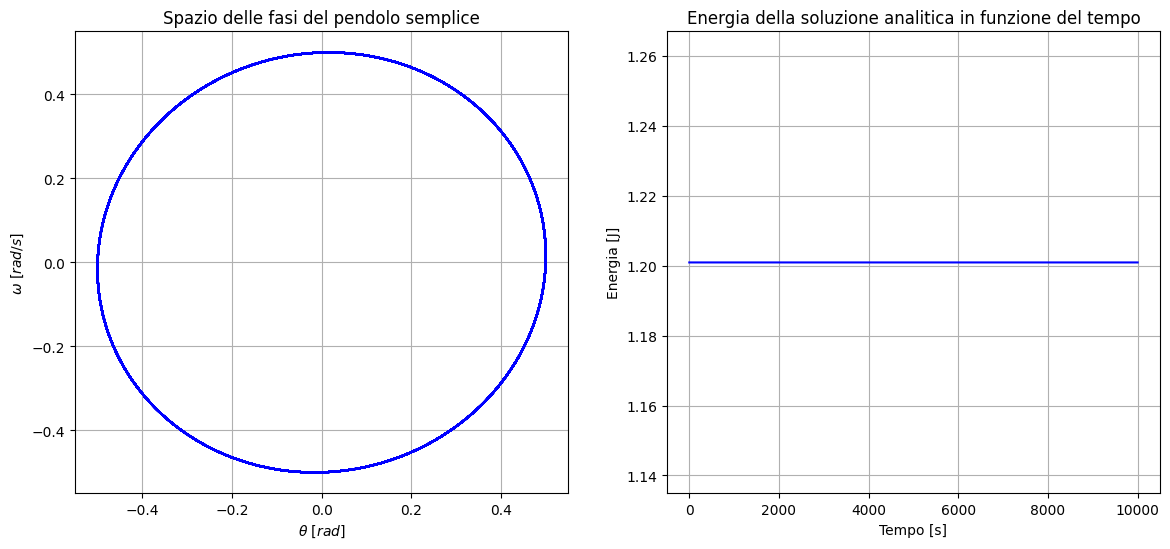

In [137]:
def vel_analitica(theta0: float, times: list[float], omega_in: float = 0) -> list[float]:
    omega0 = np.sqrt(g/L)
    v0 = 0
    vel = [v0]
    for t in times[:-1]:
        v = -theta0 * np.sin(omega0 * t) + (omega_in / omega0) * np.cos(omega0 * t)
        vel.append(v)
        v0 = v

    return np.array(vel)


pos, vel = f_analitica(theta0=theta02, times=long_times), vel_analitica(theta0=theta02, times=long_times)
energy = 0.5 * m * L**2 * vel**2 + m * g * L * (1 - np.cos(pos))
e1 = [(0.5 * m * L**2 * 0.0**2 + m * g * L * (1 - np.cos(theta02))) for _ in range(len(long_times))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(pos, vel, color="blue")
ax1.set_title("Spazio delle fasi del pendolo semplice")
ax1.grid(True)
ax1.set_xlabel(r"$\theta\ [rad]$")
ax1.set_ylabel(r"$\omega\ [rad/s]$")
ax2.plot(e1, color="blue")
ax2.set_title("Energia della soluzione analitica in funzione del tempo")
ax2.set_xlabel("Tempo [s]")
ax2.set_ylabel("Energia [J]")
ax2.grid(True)
plt.show()

Analizziamo ora l'andamento nello spazio delle fasi del metodo di Eulero e della variazione di Eulero-Cromer: dalle considerazioni fatte in precedenza ci aspettiamo una spirale che si allarga per il primo e di un'ellisse stabile per il secondo. Partiamo da Eulero-Cromer:

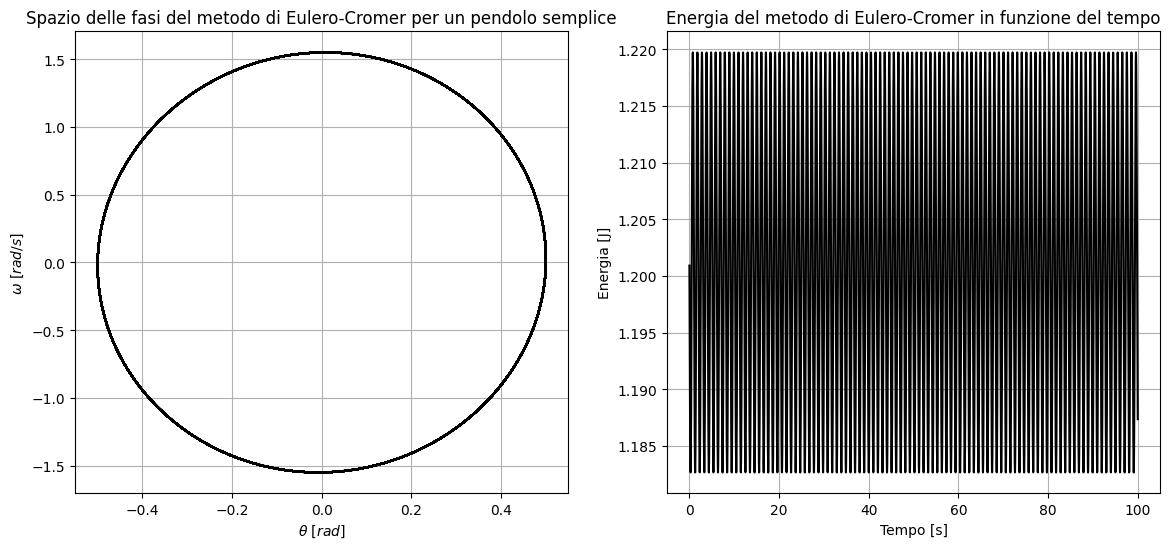

Variazione percentuale dell'energia: 1.128304753252956%


In [138]:
ec_pos, ec_vel = eulero_cromer(theta0=theta02, h=dt, times=long_times)
ec_energy = 0.5 * m * L**2 * ec_vel**2 + m * g * L * (1 - np.cos(ec_pos))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(ec_pos, ec_vel, color="black")
ax1.set_title("Spazio delle fasi del metodo di Eulero-Cromer per un pendolo semplice")
ax1.grid(True)
ax1.set_xlabel(r"$\theta\ [rad]$")
ax1.set_ylabel(r"$\omega\ [rad/s]$")
ax2.plot(long_times, ec_energy, color="black")
ax2.set_title("Energia del metodo di Eulero-Cromer in funzione del tempo")
ax2.set_xlabel("Tempo [s]")
ax2.set_ylabel("Energia [J]")
ax2.grid(True)
plt.show()

print(f"Variazione percentuale dell'energia: {abs(((ec_energy[-1] - ec_energy[0]) / ec_energy[0]) * 100)}%")

Passando al metodo di Eulero notiamo che per $h=0.01$ otteniamo un andamento complesso da interpretare mentre utilizzando $h=0.001$ notiamo la spirale divergente aspettata. Per periodi più grandi lo spessore della spirale aumenterebbe e l'effetto sarebbe più visibile.

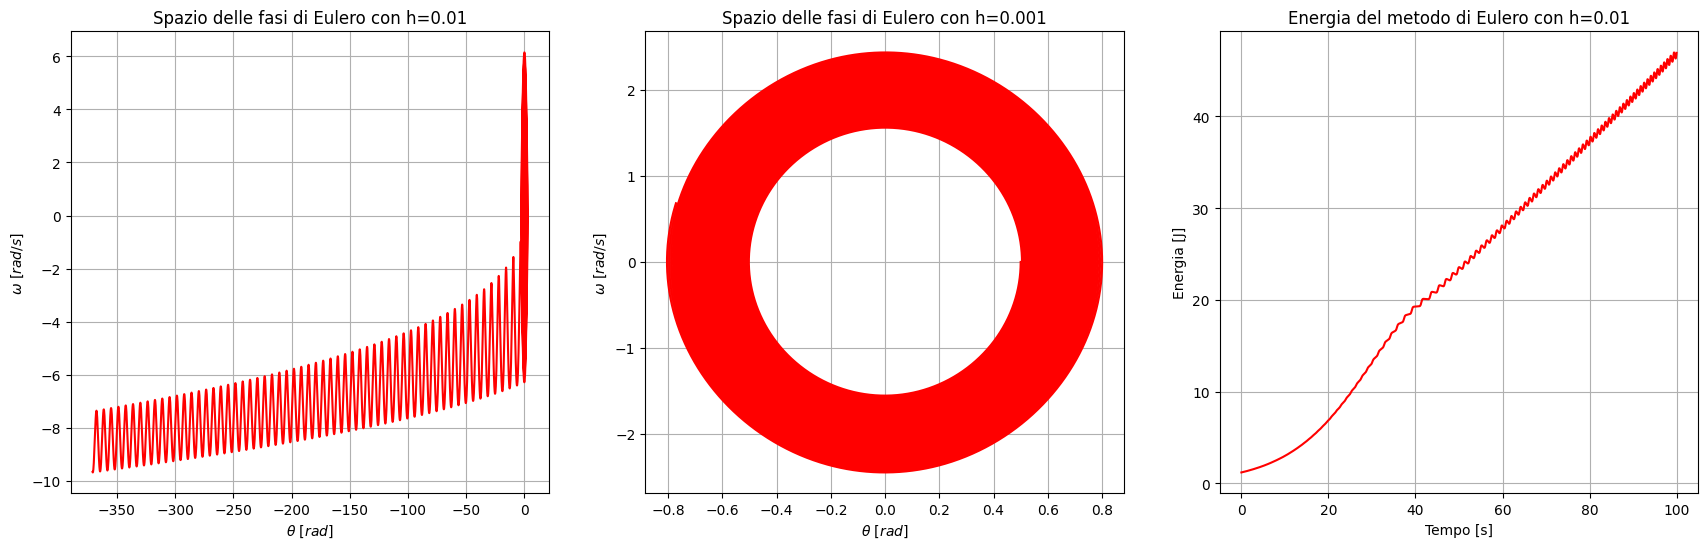

Variazione percentuale dell'energia: 3807.76522632821%


In [139]:
e_pos, e_vel = eulero(theta0=theta02, h=dt, times=long_times)
h_e_pos, h_e_vel = eulero(theta0=theta02, h=dt2, times=very_long_times)
e_energy = 0.5 * m * L**2 * e_vel**2 + m * g * L * (1 - np.cos(e_pos))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
ax1.plot(e_pos, e_vel, color="red")
ax1.set_title("Spazio delle fasi di Eulero con h=0.01")
ax1.set_xlabel(r"$\theta\ [rad]$")
ax1.set_ylabel(r"$\omega\ [rad/s]$")
ax1.grid(True)
ax2.plot(h_e_pos, h_e_vel, color="red")
ax2.set_title("Spazio delle fasi di Eulero con h=0.001")
ax2.set_xlabel(r"$\theta\ [rad]$")
ax2.set_ylabel(r"$\omega\ [rad/s]$")
ax2.grid(True)
ax3.plot(long_times, e_energy, color="red")
ax3.set_title("Energia del metodo di Eulero con h=0.01")
ax3.set_xlabel("Tempo [s]")
ax3.set_ylabel("Energia [J]")
ax3.grid(True)
plt.show()
print(f"Variazione percentuale dell'energia: {abs(((e_energy[-1] - e_energy[0]) / e_energy[0])) * 100}%")

Creiamo un grafico per confrontare l'andamento dell'energia nei tre casi:

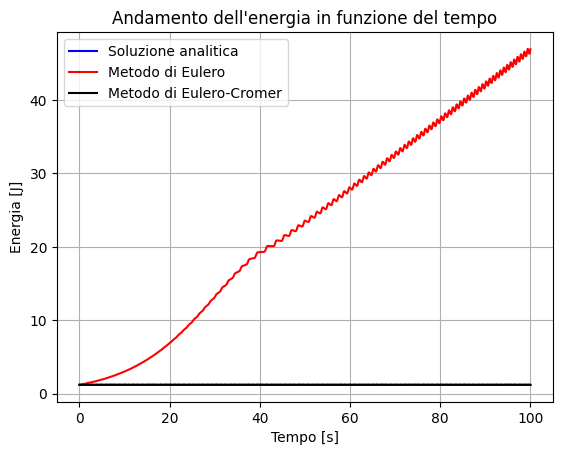

In [140]:
plt.plot(long_times, e1, label="Soluzione analitica", color="blue")
plt.plot(long_times, e_energy, label="Metodo di Eulero", color="red")
plt.plot(long_times, ec_energy, label="Metodo di Eulero-Cromer", color="black")
plt.grid()
plt.legend()
plt.xlabel("Tempo [s]")
plt.ylabel("Energia [J]")
plt.title("Andamento dell'energia in funzione del tempo")
plt.show()

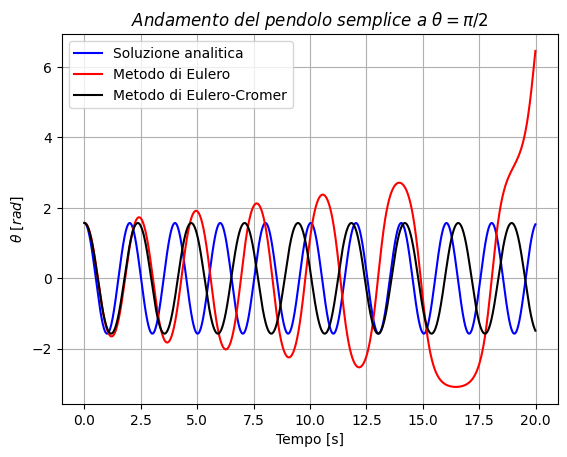

In [141]:
pi2_f_analitica = f_analitica(theta0=pi2, times=times)
pi2_eul = eulero(theta0=pi2, h=dt, times=times)[0]
pi2_ec = eulero_cromer(theta0=pi2, h=dt, times=times)[0]


plt.plot(times, pi2_f_analitica, label="Soluzione analitica", color="blue")
plt.plot(times, pi2_eul, label="Metodo di Eulero", color="red")
plt.plot(times, pi2_ec, label="Metodo di Eulero-Cromer", color="black")
plt.grid()
plt.legend()
plt.xlabel("Tempo [s]")
plt.ylabel(r"$\theta\ [rad]$")
plt.title(r"$Andamento\ del\ pendolo\ semplice\ a\ \theta=\pi/2$")
plt.show()

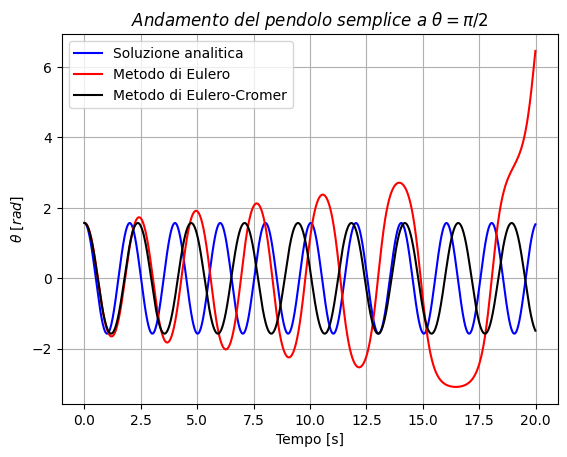

In [142]:
pi2_f_analitica = f_analitica(theta0=pi2, times=times)
pi2_eul = eulero(theta0=pi2, h=dt, times=times)[0]
pi2_ec = eulero_cromer(theta0=pi2, h=dt, times=times)[0]


plt.plot(times, pi2_f_analitica, label="Soluzione analitica", color="blue")
plt.plot(times, pi2_eul, label="Metodo di Eulero", color="red")
plt.plot(times, pi2_ec, label="Metodo di Eulero-Cromer", color="black")
plt.grid()
plt.legend()
plt.xlabel("Tempo [s]")
plt.ylabel(r"$\theta\ [rad]$")
plt.title(r"$Andamento\ del\ pendolo\ semplice\ a\ \theta=\pi/2$")
plt.show()

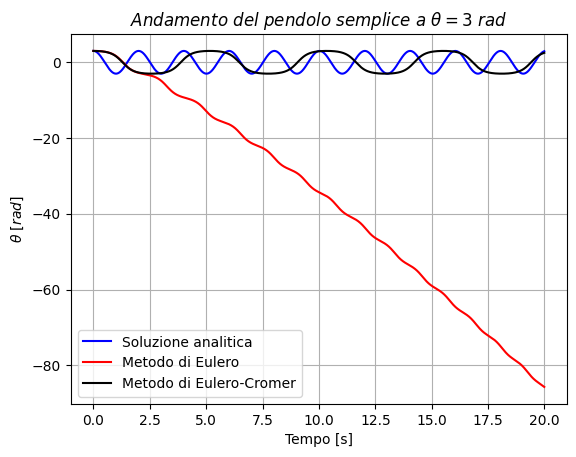

In [143]:
r_f_analitica = f_analitica(theta0=theta04, times=times)
r_eul = eulero(theta0=theta04, h=dt, times=times)[0]
r_ec = eulero_cromer(theta0=theta04, h=dt, times=times)[0]

plt.plot(times, r_f_analitica, label="Soluzione analitica", color="blue")
plt.plot(times, r_eul, label="Metodo di Eulero", color="red")
plt.plot(times, r_ec, label="Metodo di Eulero-Cromer", color="black")
plt.grid()
plt.legend()
plt.xlabel("Tempo [s]")
plt.ylabel(r"$\theta\ [rad]$")
plt.title(r"$Andamento\ del\ pendolo\ semplice\ a\ \theta=3\ rad$")
plt.show()

Notiamo che la soluzione analitica oscilla molto più velocemente rispetto al metodo di Eulero-Cromer perché usa l'approssimazione per piccoli angoli, mentre il metodo utilizza il seno dell'angolo e quindi quando si trova quasi sulla verticale l'accelerazione che riporta giù il pendolo è molto più piccola e questo rimane in alto per più tempo.